# Import Libraries

In [1570]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

df=pd.read_csv('/content/Titanic.csv')

# Explore Dataset

In [1571]:
# 01 Dataset structure
df.shape

(891, 12)

In [1572]:
# 02 Explore columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [1573]:
#2.2 data types of columns
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [1574]:
# we see that there numerical and categorical columns
numCol=df.select_dtypes(include=['number']).columns
display(numCol)
catCol=df.select_dtypes(include=['object']).columns
catCol

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [1575]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1576]:
# 2.3 get info about data in columns (helps us decide which is useful and not)
def info(dataFrame:pd.DataFrame):

  """this fun returns new data frame contain info about every col """

  names=[col for col in dataFrame]
  dataType=[dataFrame[col].dtype for col in dataFrame.columns]
  uniqueValueNum=[dataFrame[col].nunique() for col in dataFrame.columns]
  numOfNulls=[dataFrame[col].isna().sum() for col in dataFrame.columns]
  numOfDupl=[dataFrame[col].duplicated().sum() for col in dataFrame.columns]
  numFilled=[dataFrame[col].count() for col in dataFrame.columns]

  return pd.DataFrame({
      "Name":names,
      "data type":dataType,
      "number of filled cells":numFilled,
      "number of unique values":uniqueValueNum,
      "number of duplicated cells":numOfDupl,
      "number of nulls":numOfNulls
  })

info(df)


,Name,data type,number of filled cells,number of unique values,number of duplicated cells,number of nulls
0,PassengerId,int64,891,891,0,0
1,Survived,int64,891,2,889,0
2,Pclass,int64,891,3,888,0
3,Name,object,891,891,0,0
4,Sex,object,891,2,889,0
5,Age,float64,714,88,802,177
6,SibSp,int64,891,7,884,0
7,Parch,int64,891,7,884,0
8,Ticket,object,891,681,210,0
9,Fare,float64,891,248,643,0


**conclusion for every column**:

*   **PassengerId:** is like an id for every col which is useless so must drop it
*   **Survived, Sex, Pclass and embarked:** may be categorical columns
*   **Cabin, Age:** have alot of nulls, should deal with them




In [1577]:
may_Categorical=['Sex','Survived','Pclass','Embarked']
for col in may_Categorical:
  print(col,df[col].unique(),end='\n')

#Survived is a boolean categorical column >> should convert it to cat
#Pclass is ordinal category >> should convert it to cat instead of int


Sex ['male' 'female']
Survived [0 1]
Pclass [3 1 2]
Embarked ['S' 'C' 'Q' nan]


### conclusion data problems and how to handle it:
1. 'Survived' and 'Pclass' are wrong datatype. todo: convert them to category
2. 'PassengerId' is useless column. todo: drop it.
3. to do: dealing with nuls in 'Cabin', 'Age' and 'Embarked' columns
4. to do: check mean, variance , outliers and deal with them

# Make Analysis and Visualizations to get Information about the data


> this section will be more focused on visualization and explore decision for handling outliers and nulls.


#### understanding and handling numerical columns

In [1578]:
df[numCol].describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


<Axes: ylabel='Age'>

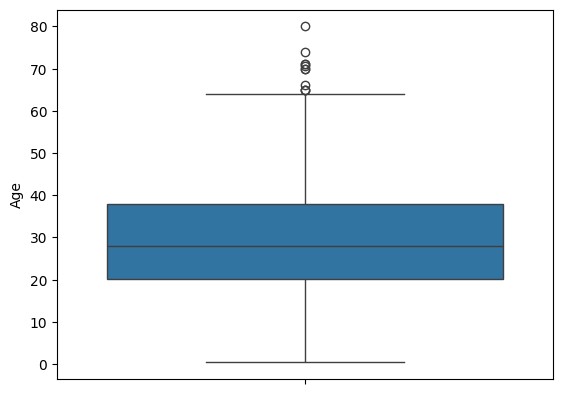

In [1579]:
#01 understanding "Age" column
sns.boxplot(y='Age',data=df)

#no need for handling outliers, since they exist in real life

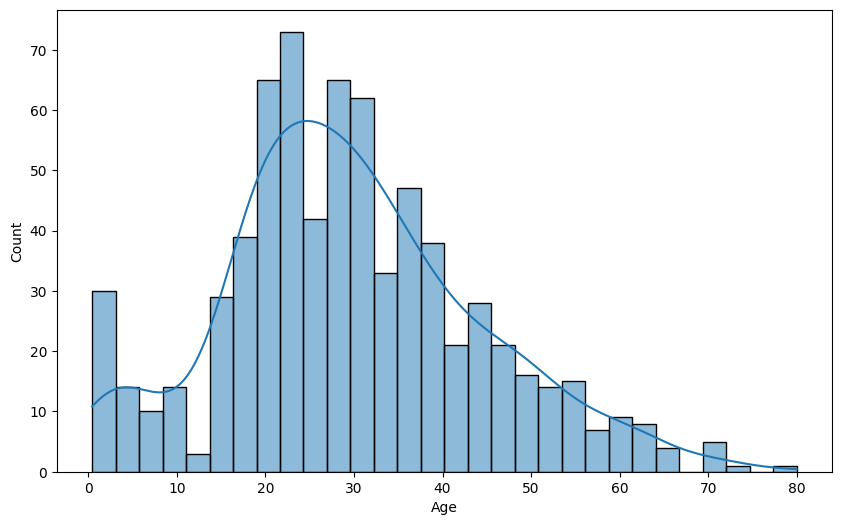

In [1580]:
#Age has 177 nulls
#check the distributive of the age column
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.show()
# The Age column is almost normally distributed, so we can fill the null values with the mean

<Axes: xlabel='Pclass', ylabel='Fare'>

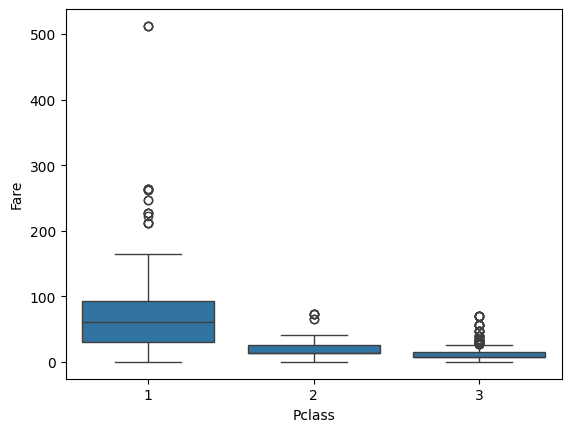

In [1581]:
sns.boxplot(y='Fare',x='Pclass',data=df)

#the very high outlier should be deleted, may affect the predictions

<Axes: xlabel='Pclass', ylabel='count'>

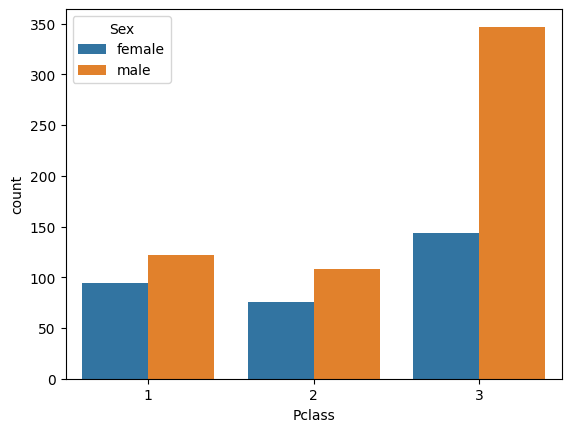

In [1582]:
sns.countplot(hue='Sex',x='Pclass',data=df)

####understanding and handling categorical columns

In [1583]:
df[catCol].describe().T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


<Axes: xlabel='Sex', ylabel='count'>

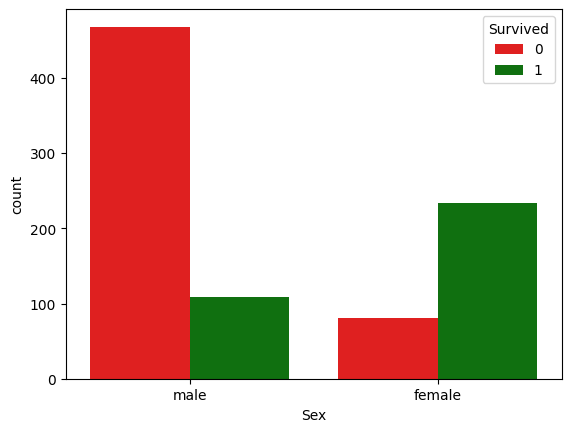

In [1584]:
#see if there is a relation between gender and surviving rate
#by count plot
sns.countplot(x='Sex',hue='Survived',data=df,palette=['red','green'])

#the chance for women is much bigger than men to survive

<Axes: xlabel='Pclass', ylabel='count'>

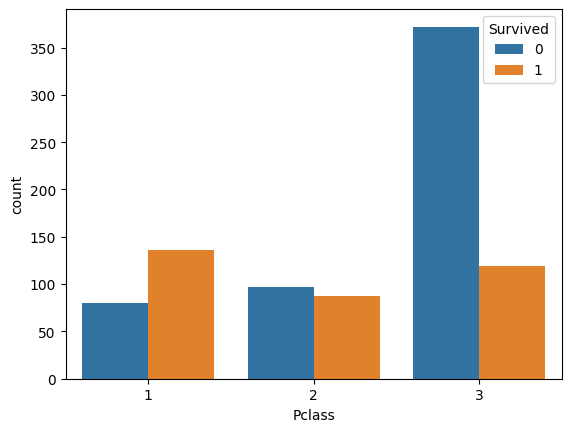

In [1585]:
sns.countplot(x='Pclass',hue='Survived',data=df)
# Passengers in third class had the lowest survival rate

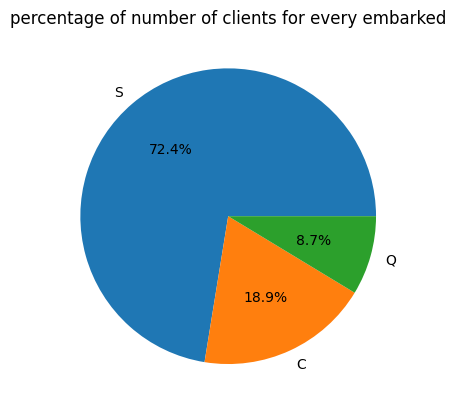

In [1586]:
count=df['Embarked'].value_counts()
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('percentage of number of clients for every embarked')
plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

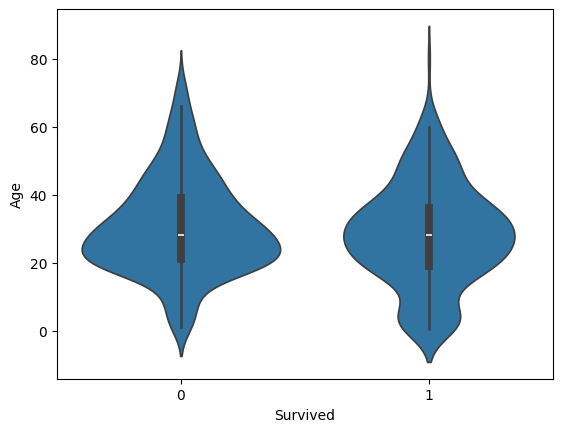

In [1587]:
sns.violinplot(x='Survived',y='Age',data=df)

# Make Preprocessing (Nulls, Duplicates, Outliers)

#### in this step, we gonna handle the problem we discovered


1.   drop the **"PassengerId"** column
2.   convert **"Survived"** to boolean and **"Pclass"** to category
3.   fill the nulls in **"Embarked"** with mode
4.   drop the max value in **"Fare"** column
5.   fill nulls in age column group by sex and fill it with median of each gender




In [1588]:
#01 drop the "PassengerId" column
df.drop('PassengerId',axis=1,inplace=True)

In [1589]:
#02 convert "Survived" to boolean and "Pclass" to category
df['Survived']=df['Survived'].astype('boolean')
df['Pclass']=df['Pclass'].astype('category')

In [1590]:
#03 fill the nulls in "Embarked" with mode
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [1591]:
#04 fare outliers
# first check if there more than one value for the very high outlier
max_fare = df['Fare'].max()
outliers_df = df[df['Fare'] == max_fare].copy()
outliers_df


#same ticket?? maybe they all are family
#but parch and sibsp mostly zero!

#the final conclusion:
# The three passengers share the same ticket (PC 17755).
# The fare was divided by the number of passengers to convert group ticket price into individual fare, making the data more accurate for analysis


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,True,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,True,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,True,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [1592]:
# need to fix this problem generally on all the values in the 'Fare' column and divide the price of the same tickets per persons
duplicate_tickets=df.groupby('Ticket')['Fare'].apply(lambda x:x.index.tolist()).to_dict()

for ticket,indices in duplicate_tickets.items():
   groupSize=len(indices)
   price=df.loc[indices[0],'Fare']
   df.loc[indices, 'Fare'] = price/groupSize

<Axes: xlabel='Pclass', ylabel='Fare'>

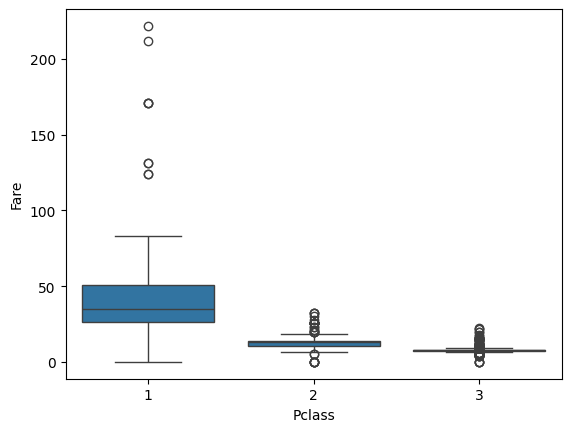

In [1593]:
sns.boxplot(y='Fare',x='Pclass',data=df)

<Axes: xlabel='Pclass', ylabel='Fare'>

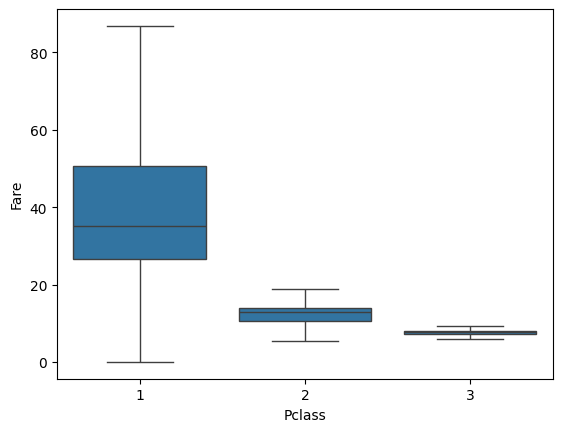

In [1594]:
#dealing with Fare's outliers: capping outliers per class
#because the normal ticket in class1 can be an outlier for the fare in class3 so we should handle every class alone to prevent treating normal value in one class as outliers in another
Q1=df.groupby('Pclass',observed=False)['Fare'].quantile(0.25)
Q3=df.groupby('Pclass',observed=False)['Fare'].quantile(0.75)
IQR=Q3-Q1
upperF=Q3+1.5*IQR
lowerF=Q1-1.5*IQR
newFare=df.groupby('Pclass',observed=False)['Fare'].transform(lambda x: x.clip(lower=lowerF[x.name],upper=upperF[x.name]))
df['Fare']=newFare

#visualize the newdata
sns.boxplot(y='Fare',x='Pclass',data=df)

In [1595]:
#05 fill nulls in age column group by sex and fill it with median of each gender
df['Age']=df.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.mean()))


/tmp/ipykernel_631/550309626.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Age']=df.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.mean()))


In [1596]:
#06 drop duplicates
df.duplicated().sum()
#no need to drop since there are no duplicates

np.int64(0)

In [1597]:
#the nulls in cabin
(df['Cabin'].isna().sum()/891)*100 #percentage of nulls=77.1%
#since it has nulls more than half the number of rows then i decided to drop this column
df.drop('Cabin',axis=1,inplace=True)

# Feature Engineering

In [1598]:
#checking the current data
info(df)

,Name,data type,number of filled cells,number of unique values,number of duplicated cells,number of nulls
0,Survived,boolean,891,2,889,0
1,Pclass,category,891,3,888,0
2,Name,object,891,891,0,0
3,Sex,object,891,2,889,0
4,Age,float64,891,94,797,0
5,SibSp,int64,891,7,884,0
6,Parch,int64,891,7,884,0
7,Ticket,object,891,681,210,0
8,Fare,float64,891,198,693,0
9,Embarked,object,891,3,888,0


In [1599]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace([
    'Lady','Countess','Capt','Col','Don','Dr',
    'Major','Rev','Sir','Jonkheer','Dona'
], 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle':'Miss',
    'Ms':'Miss',
    'Mme':'Mrs'
})

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_631/3342241334.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [1600]:
df['FamilySize']=df['SibSp']+df['Parch']+1

df['isAlone']=df['FamilySize']==1
df['isAlone'] = df['isAlone'].astype('int')

info(df)

,Name,data type,number of filled cells,number of unique values,number of duplicated cells,number of nulls
0,Survived,boolean,891,2,889,0
1,Pclass,category,891,3,888,0
2,Name,object,891,891,0,0
3,Sex,object,891,2,889,0
4,Age,float64,891,94,797,0
5,SibSp,int64,891,7,884,0
6,Parch,int64,891,7,884,0
7,Ticket,object,891,681,210,0
8,Fare,float64,891,198,693,0
9,Embarked,object,891,3,888,0


# Split Data

In [1601]:
df.drop(['Ticket','Name'],axis=1,inplace=True) #so the model can focus more on the numerical features and the encoded categorical columns.
display(info(df))
print()
display(df.duplicated().sum())
df.drop_duplicates(inplace=True) #remove duplicated rows

,Name,data type,number of filled cells,number of unique values,number of duplicated cells,number of nulls
0,Survived,boolean,891,2,889,0
1,Pclass,category,891,3,888,0
2,Sex,object,891,2,889,0
3,Age,float64,891,94,797,0
4,SibSp,int64,891,7,884,0
5,Parch,int64,891,7,884,0
6,Fare,float64,891,198,693,0
7,Embarked,object,891,3,888,0
8,Title,object,891,5,886,0
9,FamilySize,int64,891,9,882,0


np.int64(109)

our target is define the Survival of the given case
so i splitted the data 70% for training and 30% for testing and our target is **"Survived"** column

In [1602]:
x=df.drop('Survived',axis=1)
y=df['Survived'] #target
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.3,
                                                 random_state=42)

# Encoding

* [Pclass] mapping to [1,2,3] >> ordinal encoder
* [sex] mapping to [0,1] (0 if male else 1)   >>label encoder
* [Embarked] mapping to one hot encoding method >>reason (we only have 3 types of it)


In [1603]:
#since Pclass is already encoding we just convert it from category to int so the model can understand it
x_train['Pclass']=x_train['Pclass'].astype('int')
x_test['Pclass']=x_test['Pclass'].astype('int')
#label encoding for sex
le=LabelEncoder()
x_train['Sex']=le.fit_transform(x_train['Sex'])
x_test['Sex']=le.transform(x_test['Sex'])

In [1604]:
#one hot encoding for Embarked

oneHotEncoder= OneHotEncoder(handle_unknown='ignore',sparse_output=False)
x_train_encoded=oneHotEncoder.fit_transform(x_train[['Embarked','Title']])
x_test_encoded= oneHotEncoder.transform(x_test[['Embarked','Title']])
encoded_cols=list(oneHotEncoder.get_feature_names_out(['Embarked','Title']))
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=encoded_cols,
    index=x_train.index
)

x_test_encoded = pd.DataFrame(
    x_test_encoded,
    columns=encoded_cols,
    index=x_test.index
)
x_train.drop(columns=['Title','Embarked'],inplace=True)
x_test.drop(columns=['Title','Embarked'],inplace=True)

x_train = pd.concat([x_train, x_train_encoded], axis=1)
x_test  = pd.concat([x_test, x_test_encoded], axis=1)
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,isAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
24,3,0,8.0,3,1,6.050000,5,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
268,1,0,58.0,0,1,51.154167,2,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
492,1,1,55.0,0,0,30.500000,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
362,3,0,45.0,0,1,7.227100,2,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
676,3,1,24.5,0,0,8.050000,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,2,1,21.0,0,0,14.700000,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
112,3,1,22.0,0,0,8.050000,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
285,3,1,33.0,0,0,8.662500,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
478,3,1,22.0,0,0,7.520800,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Scaling

In [1605]:
#scaling for fare,age

scaler = StandardScaler()
scaleCols=['Age','Fare']
x_train[scaleCols]= scaler.fit_transform(x_train[scaleCols])
x_test[scaleCols]= scaler.transform(x_test[scaleCols])


# Measure correlation

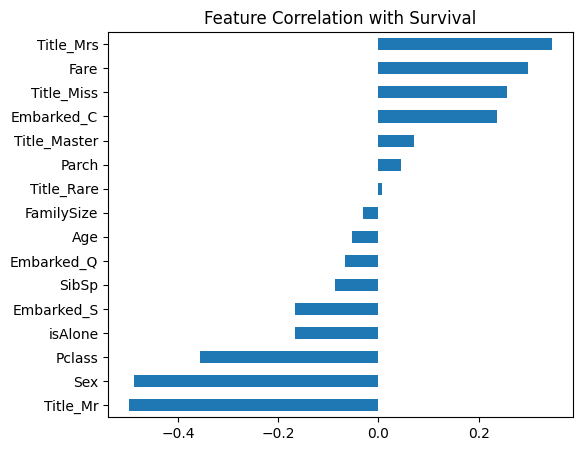

In [1606]:
corr = x_train.corrwith(y_train).sort_values()

plt.figure(figsize=(6,5))
corr.plot(kind='barh')
plt.title("Feature Correlation with Survival")
plt.show()

correlation with target:


*   Fare has the highest positive correlation with target
*   Sex is the most correlated feature with target
*   other features are not correlated with target as well



# Balance Data (if needed)

In [1620]:
df['Survived'].value_counts()

#not a big differance so no need for balancing the data

,count
Survived,
False,456
True,326


# Modeling

In [1608]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [1609]:
y_pred=model.predict(x_test)

# Evaluation

#### 01 Accuracy Score

In [1610]:
train_acc = model.score(x_train, y_train)
test_acc = model.score(x_test, y_test)

print("Test:", test_acc)
print("Train:", train_acc)

Test: 0.7659574468085106
Train: 0.8263254113345521


#### 02 Classification Report

In [1611]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.80      0.78       123
         1.0       0.77      0.72      0.75       112

    accuracy                           0.77       235
   macro avg       0.77      0.76      0.76       235
weighted avg       0.77      0.77      0.77       235



#### 03 Confusion Matrix

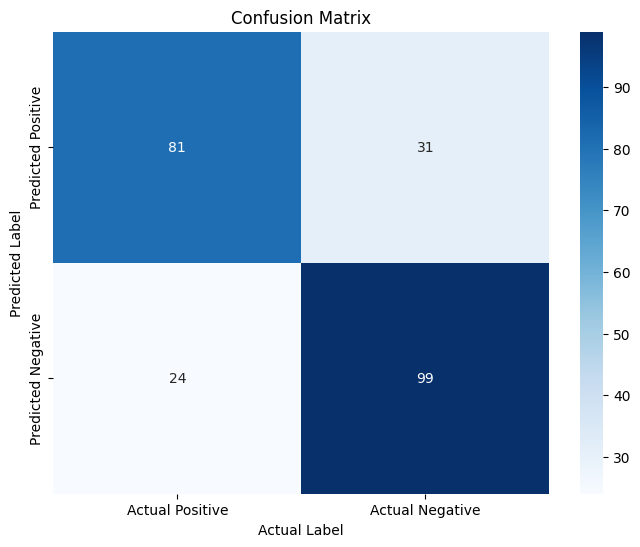

In [1612]:
#Confusion Matrix

cm=confusion_matrix(y_test,y_pred)

cm_reordered = np.array([[cm[1][1], cm[0][1]],
                         [cm[1][0], cm[0][0]]])

cm_transposed = cm_reordered.T

plt.figure(figsize=(8, 6))
sns.heatmap(cm_transposed, annot=True, cmap="Blues",
            xticklabels=["Actual Positive", "Actual Negative"],
            yticklabels=["Predicted Positive", "Predicted Negative"])
plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()
#  [[TP, FP],
#  [FN, TN]]

#### AUC-ROC Curve

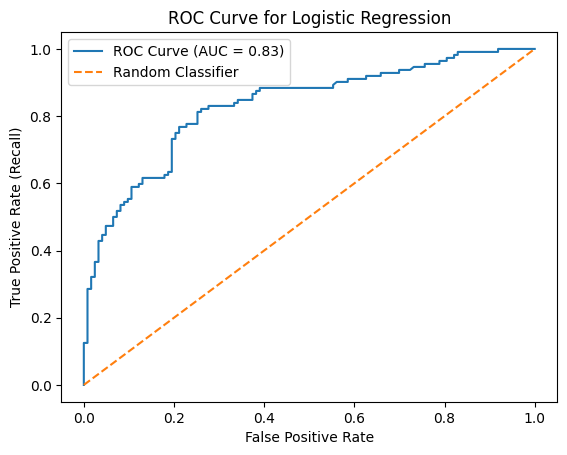

In [1613]:

y_prob = model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#calc area under the curve
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc))

plt.plot([0, 1], [0, 1], linestyle='--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()


# Insights



*   Logistic Regression was selected as the final model because it provided stable and interpretable results for this binary classification problem.
* The model achieved an accuracy of approximately 77%, which is considered reasonable given the relatively small dataset size.
* The dataset analysis showed that the number of passengers who did not survive was higher than the number of survivors.
* Gender was one of the most influential features in predicting survival. Female passengers had a significantly higher survival rate compared to male passengers.
* Ticket fare also had a strong relationship with survival probability.Passengers with higher ticket fares were more likely to survive.
* Passenger class had a noticeable impact on survival. Third-class passengers had the lowest survival rate among all classes.
* Feature engineering techniques such as extracting titles from passenger names and creating family-related features helped improve model performance.
* The model showed acceptable generalization performance with a relatively small gap between training and testing accuracy.
* ROC-AUC score reached approximately 0.83, indicating good classification capability.


